# Medicine Defect Detection using YOLOv8

This notebook demonstrates how to train a YOLOv8 model for medicine defect detection (e.g., BROKEN, Empty, OK, strip) using the provided dataset.

In [1]:
%pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO('yolov8n.pt')  # build from YAML and transfer weights

# Train the model with reduced batch size and workers to prevent OutOfMemory errors
model.train(data='../final_dataset.v1i.yolov8/data.yaml', epochs=50, imgsz=640, batch=8, workers=0)

New https://pypi.org/project/ultralytics/8.4.24 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.252  Python-3.13.5 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../final_dataset.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2,

Create a Git repo (`git init`) and commit (`git commit`).


DVCLive is detected and auto logging is enabled (run 'yolo settings dvc=False' to disable).
Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f 

AttributeError: 'NoneType' object has no attribute 'add'

In [ ]:
# Evaluate the model's performance on the validation set
metrics = model.val()
print(metrics.box.map)    # mAP50-95
print(metrics.box.map50)  # mAP50

Ultralytics 8.3.252  Python-3.13.5 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 13,260 gradients, 8.1 GFLOPs

WARNING Dataset 'coco.yaml' images not found, missing path 'C:\Users\Admin\Desktop\College\SGP\datasets\coco\val2017.txt'
Unzipping C:\Users\Admin\Desktop\College\SGP\datasets\coco2017labels-segments.zip to C:\Users\Admin\Desktop\College\SGP\datasets\coco...: 100% ━━━━━━━━━━━━ 122232/122232 1.6Kfiles/s 1:18<0.0ss

In [ ]:
import glob
import os

valid_images = glob.glob('../final_dataset.v1i.yolov8/valid/images/*.jpg')
if valid_images:
    sample_img = valid_images[0]
    results = model.predict(source=sample_img, save=True)
    print(f"Prediction saved to {results[0].save_dir}")
else:
    print("No images found in the validation folder for prediction tests.")

## Live Camera Detection

Run the cell below to open your webcam and perform real-time defect detection using your trained YOLOv8 model. Press the `q` key to stop the camera.

In [9]:
import cv2
from ultralytics import YOLO

model = YOLO(r'C:\Users\Admin\Desktop\Projects\PHARMAVISION DEFECT DETECTION\Training\runs\detect\train2\weights\best.pt')

cap = cv2.VideoCapture(0)

print("Starting live detection. Select the opened camera window and press 'q' to stop.")

while cap.isOpened():
    success, frame = cap.read()
    if success:
        results = model(frame)
        
        annotated_frame = results[0].plot()
        
        cv2.imshow("Medicine Defect Detection Live", annotated_frame)
        
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    else:
        print("Failed to grab a frame from the camera.")
        break

cap.release()
cv2.destroyAllWindows()

Starting live detection. Select the opened camera window and press 'q' to stop.

0: 480x640 (no detections), 97.7ms
Speed: 2.5ms preprocess, 97.7ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Empty, 18.3ms
Speed: 2.6ms preprocess, 18.3ms inference, 5.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 16.0ms
Speed: 2.9ms preprocess, 16.0ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Empty, 1 OK, 1 strip, 10.9ms
Speed: 2.0ms preprocess, 10.9ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Empty, 1 strip, 11.8ms
Speed: 1.6ms preprocess, 11.8ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 Emptys, 1 strip, 12.5ms
Speed: 1.8ms preprocess, 12.5ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Empty, 1 strip, 10.1ms
Speed: 1.6ms preprocess, 10.1ms inference, 2.1ms postprocess per image at shape (1,

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Results saved to C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection\Training\runs\detect\predict17


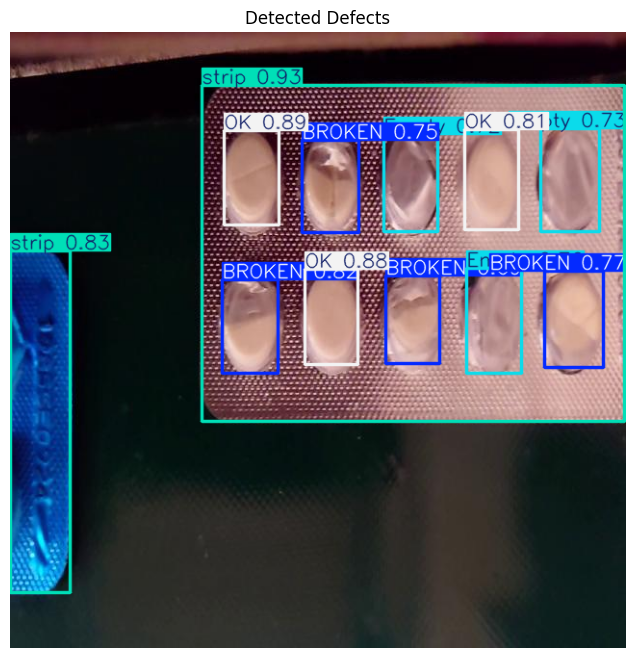

Detections: 12
Saved result to: C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection\Training\runs\detect\predict17


In [2]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Trained weights from your latest run
BEST_WEIGHTS_PATH = Path(r"C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection\Training\runs\detect\train2\weights\best.pt")

_model_for_upload = None


def detect_uploaded_image(image_path, conf=0.25, save=True, show=True):
    """Run defect detection on a single uploaded image.

    Args:
        image_path (str | Path): Path to the uploaded image.
        conf (float): Confidence threshold.
        save (bool): Save prediction output under runs/detect/predict*.
        show (bool): Display annotated image in the notebook.

    Returns:
        ultralytics.engine.results.Results: The first prediction result.
    """
    global _model_for_upload

    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    if not BEST_WEIGHTS_PATH.exists():
        raise FileNotFoundError(f"Weights not found: {BEST_WEIGHTS_PATH}")

    if _model_for_upload is None:
        _model_for_upload = YOLO(str(BEST_WEIGHTS_PATH))

    results = _model_for_upload.predict(source=str(image_path), conf=conf, save=save, verbose=False)
    result = results[0]

    if show:
        annotated = result.plot()
        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title("Detected Defects")
        plt.show()

    print(f"Detections: {len(result.boxes)}")
    if save:
        print(f"Saved result to: {result.save_dir}")

    return result


# Example usage after you upload an image:
result = detect_uploaded_image(r"C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection\final_dataset.v1i.yolov8\valid\images\frame_0020_jpg.rf.6594b3ecd19cefc05aa20a9ffd8de1f8.jpg", conf=0.25)